In [9]:
# Listar todos os arquivos de saída gerados
output_files = list(OUTPUT_BASE_DIR.rglob(f"*.{OUTPUT_FORMAT}"))
output_files.sort()

print(f"Total de arquivos de saída: {len(output_files)}\n")

# Mostrar os primeiros e últimos arquivos gerados
if len(output_files) > 0:
    print("Primeiros 5 arquivos gerados:")
    for i, f in enumerate(output_files[:5], 1):
        rel_path = f.relative_to(OUTPUT_BASE_DIR)
        size_kb = f.stat().st_size / 1024
        print(f"  {i}. {rel_path} ({size_kb:.1f} KB)")
    
    if len(output_files) > 10:
        print(f"  ...")
        print("Últimos 5 arquivos gerados:")
        for i, f in enumerate(output_files[-5:], len(output_files)-4):
            rel_path = f.relative_to(OUTPUT_BASE_DIR)
            size_kb = f.stat().st_size / 1024
            print(f"  {i}. {rel_path} ({size_kb:.1f} KB)")

print(f"\nTamanho total dos gráficos: {sum(f.stat().st_size for f in output_files) / (1024*1024):.2f} MB")

Total de arquivos de saída: 0


Tamanho total dos gráficos: 0.00 MB


## 7. Visualização de Alguns Gráficos Gerados

In [10]:
# Criar resumo em tabela
summary_df = pd.DataFrame(plots_info)

print("\n" + "="*100)
print("RESUMO FINAL DA ANÁLISE")
print("="*100)

print(f"\nTotal de arquivos CSV processados: {len(data_storage)}")
print(f"Total de gráficos gerados: {len(plots_info)}")
print(f"Diretório de saída: {OUTPUT_BASE_DIR}\n")

print("Detalhes dos gráficos gerados:")
print(summary_df[['file', 'centrality', 'n_points', 'has_stat_error', 'has_syst_error']].to_string(index=False))

# Estatísticas
print("\n" + "-"*100)
print("ESTATÍSTICAS DE ERRO")
print("-"*100)
print(f"Gráficos com erro estatístico: {summary_df['has_stat_error'].sum()} / {len(summary_df)}")
print(f"Gráficos com erro sistemático: {summary_df['has_syst_error'].sum()} / {len(summary_df)}")
print(f"Pontos de dados médios por gráfico: {summary_df['n_points'].mean():.1f}")
print(f"Total de pontos de dados: {summary_df['n_points'].sum()}")

print("\n" + "="*100)
print("✓ Análise concluída com sucesso!")
print("="*100)


RESUMO FINAL DA ANÁLISE

Total de arquivos CSV processados: 13
Total de gráficos gerados: 0
Diretório de saída: /Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Atlas-ins1759506-plots

Detalhes dos gráficos gerados:


KeyError: "None of [Index(['file', 'centrality', 'n_points', 'has_stat_error', 'has_syst_error'], dtype='str')] are in the [columns]"

## 6. Resumo da Execução e Validação

Gerando gráficos...

✗ Table01.csv          | Erro: 'stat._+'
✗ Table02.csv          | Erro: 'stat._+'
✗ Table03.csv          | Erro: 'stat._+'
✗ Table04.csv          | Erro: 'stat._+'
✗ Table05.csv          | Erro: 'stat._+'
✗ Table06.csv          | Erro: 'stat._+'
✗ Table07.csv          | Erro: 'stat._+'
✗ Table08.csv          | Erro: 'stat._+'
✗ Table09.csv          | Erro: 'stat._+'
✗ Table10.csv          | Erro: 'stat._+'
✗ Table15.csv          | Erro: 'stat._+'
✗ Table16.csv          | Erro: 'stat._+'
✗ Table17.csv          | Erro: 'stat._+'

✓ Total de gráficos gerados: 0


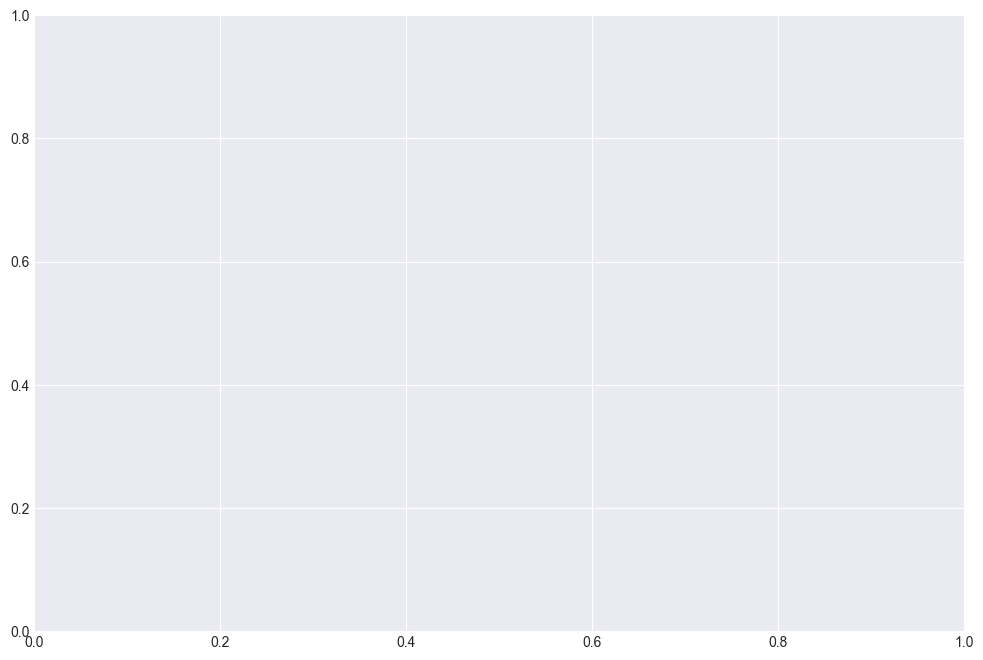

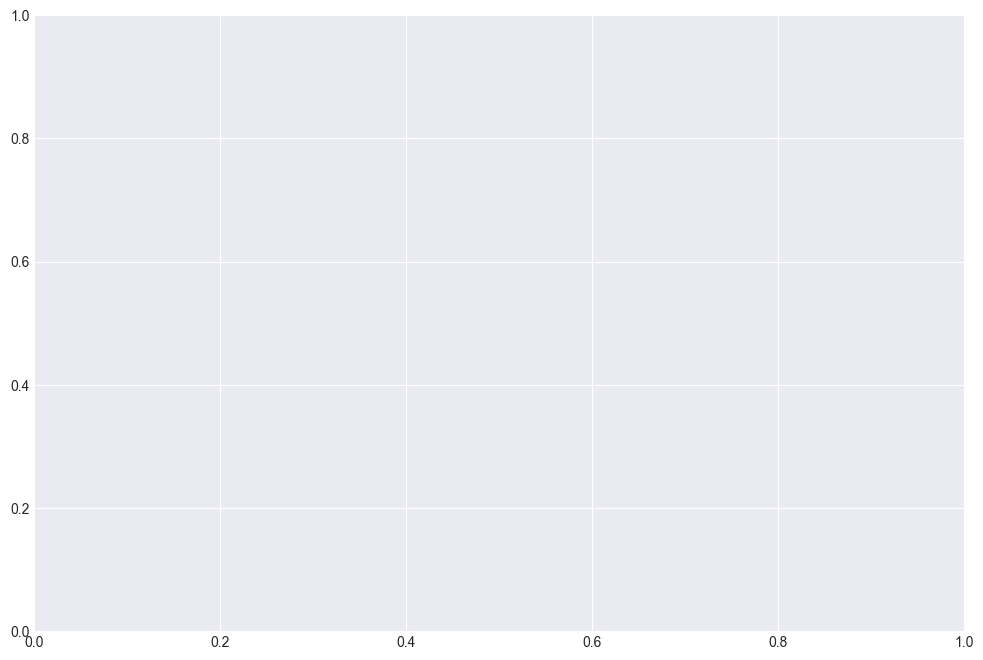

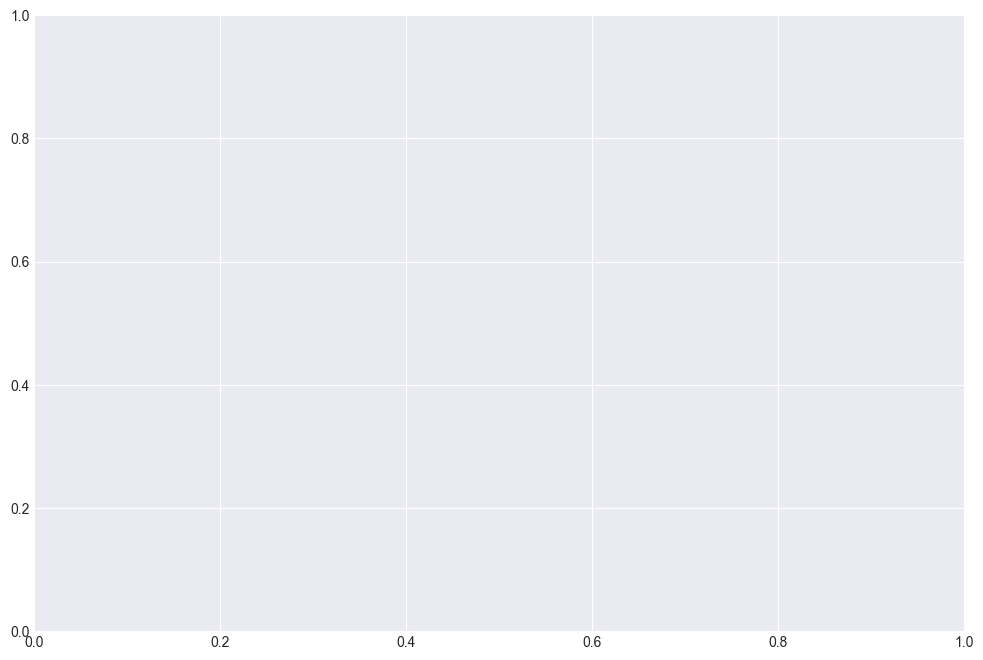

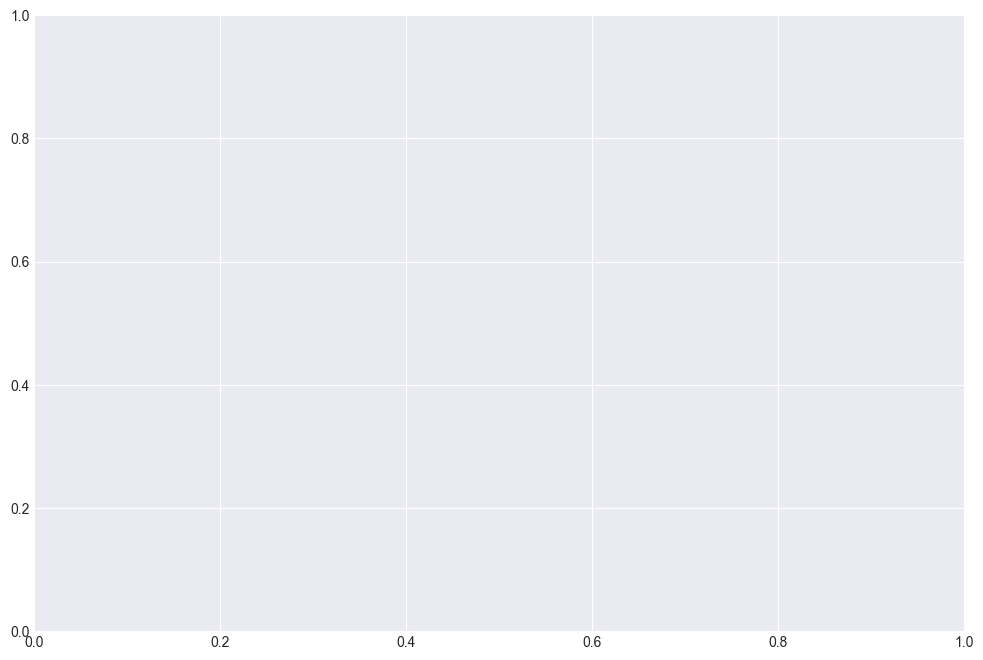

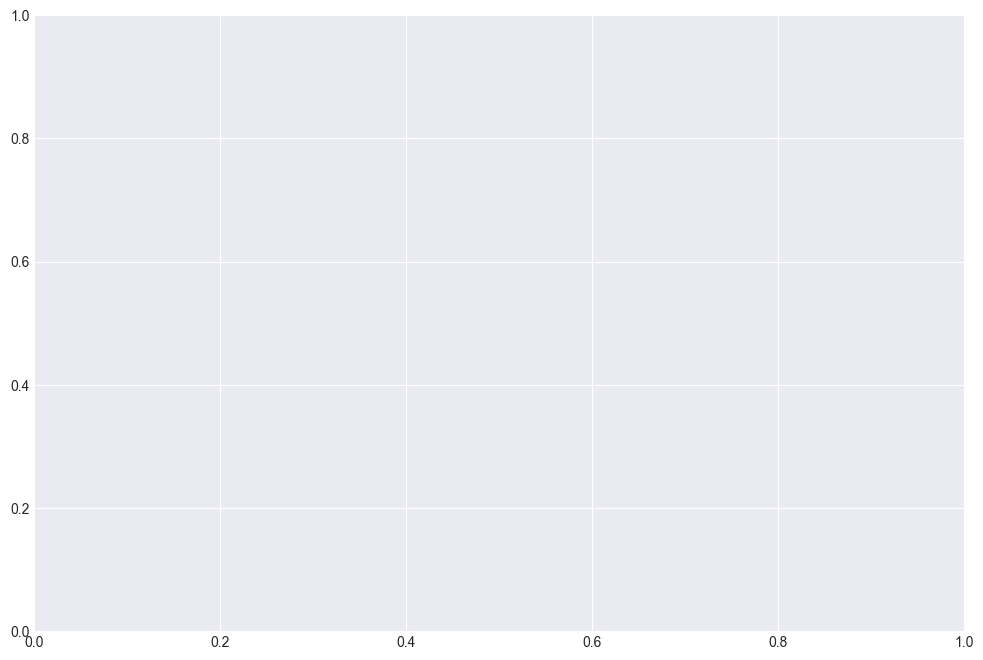

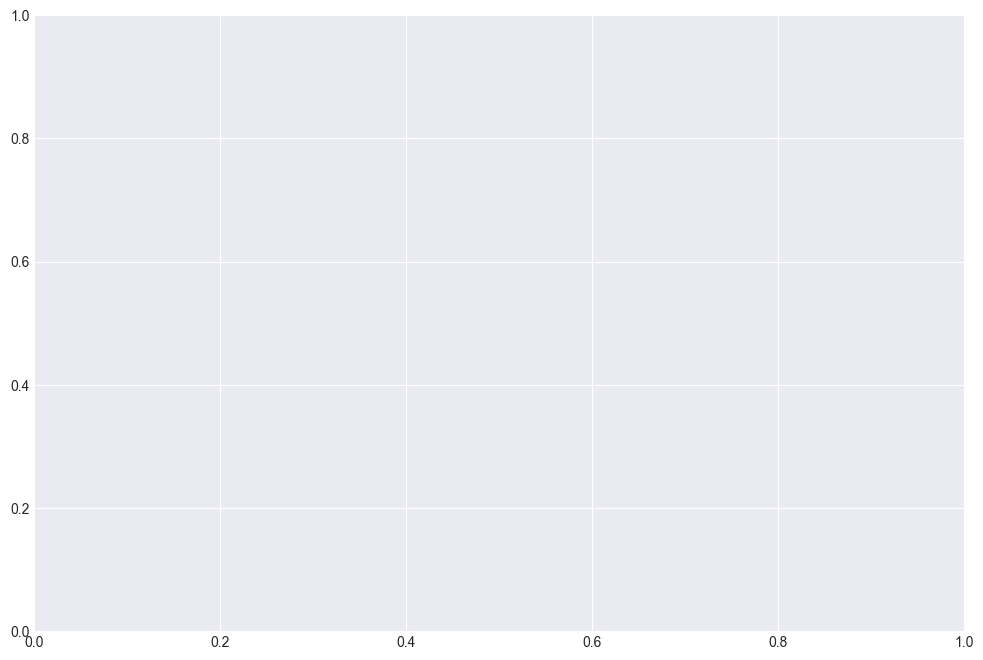

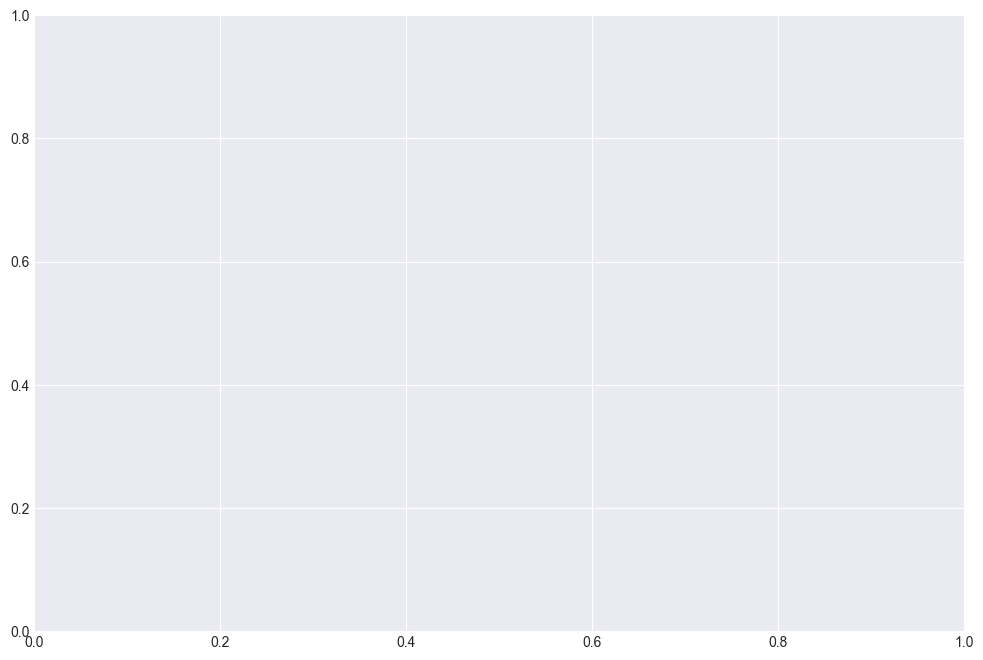

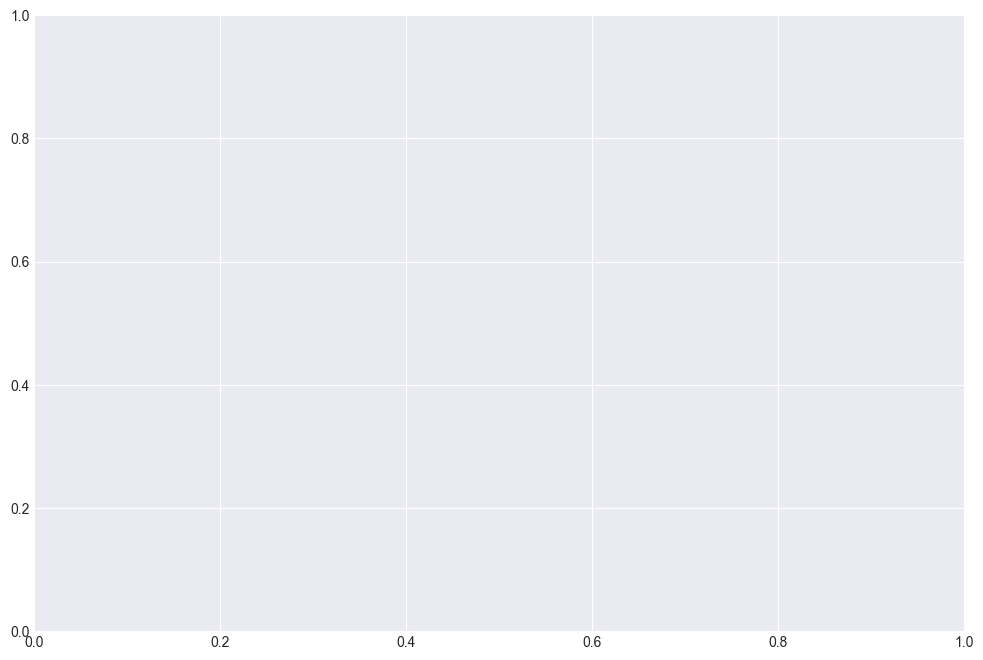

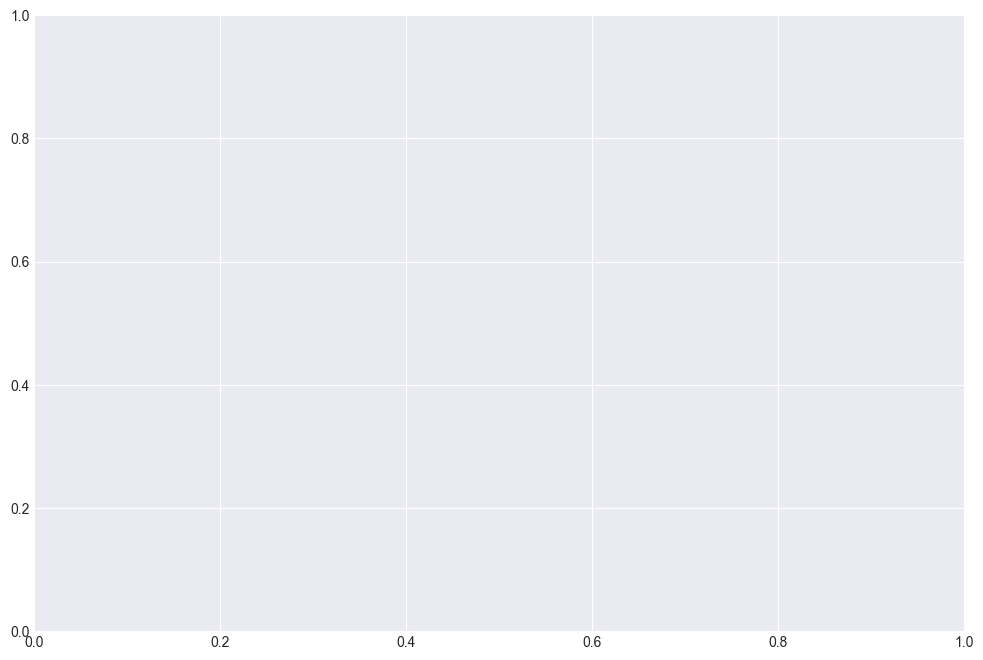

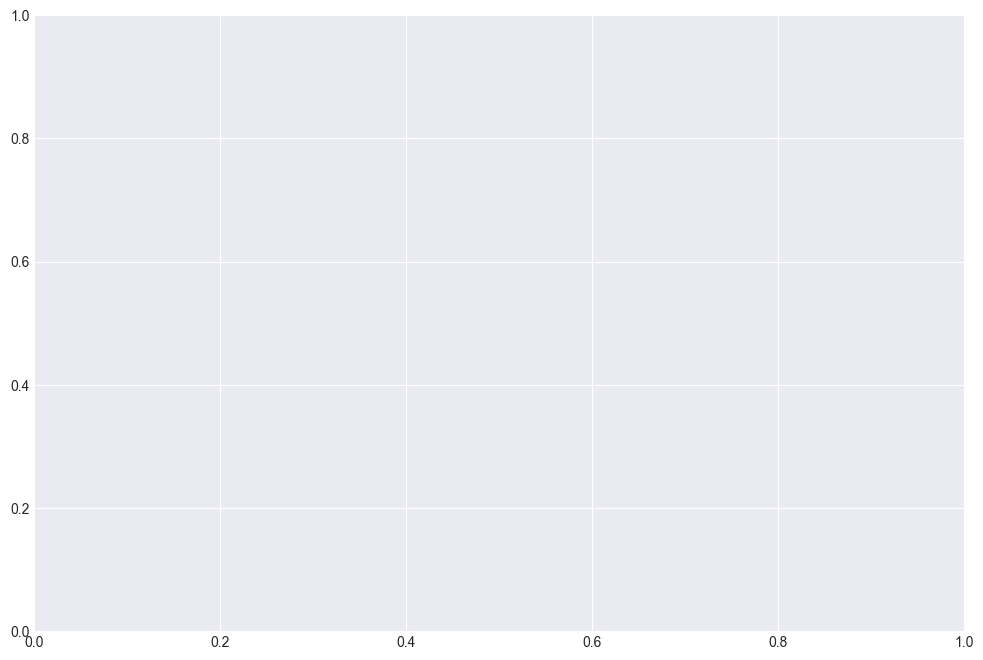

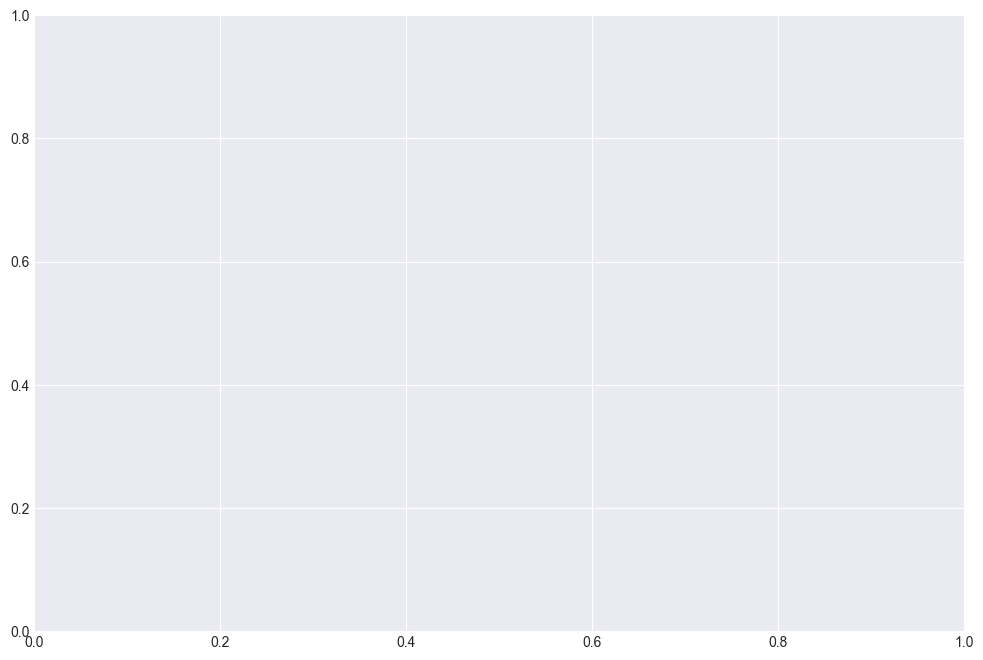

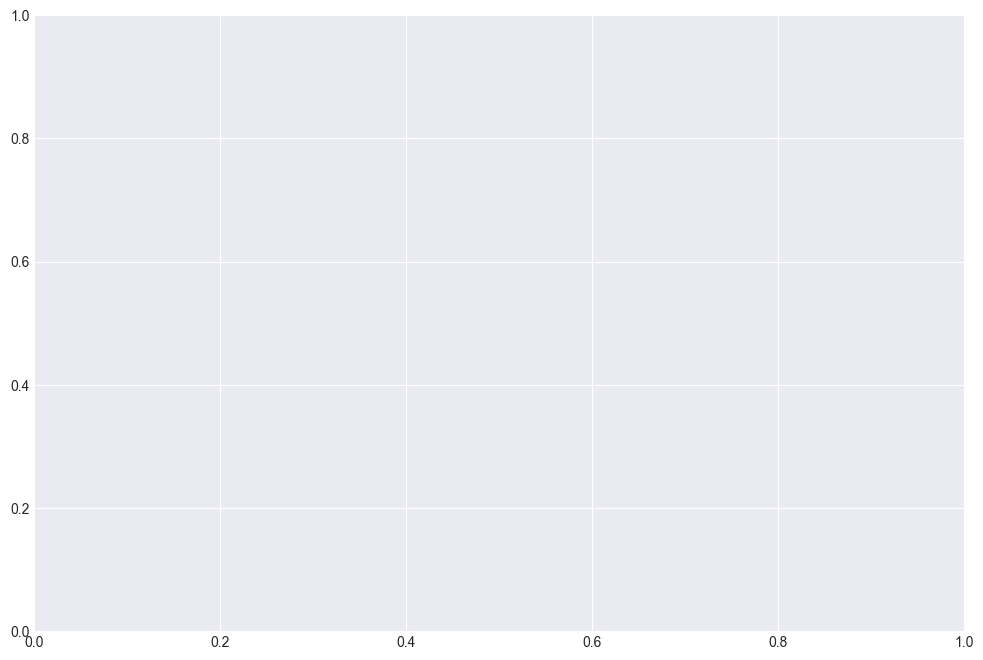

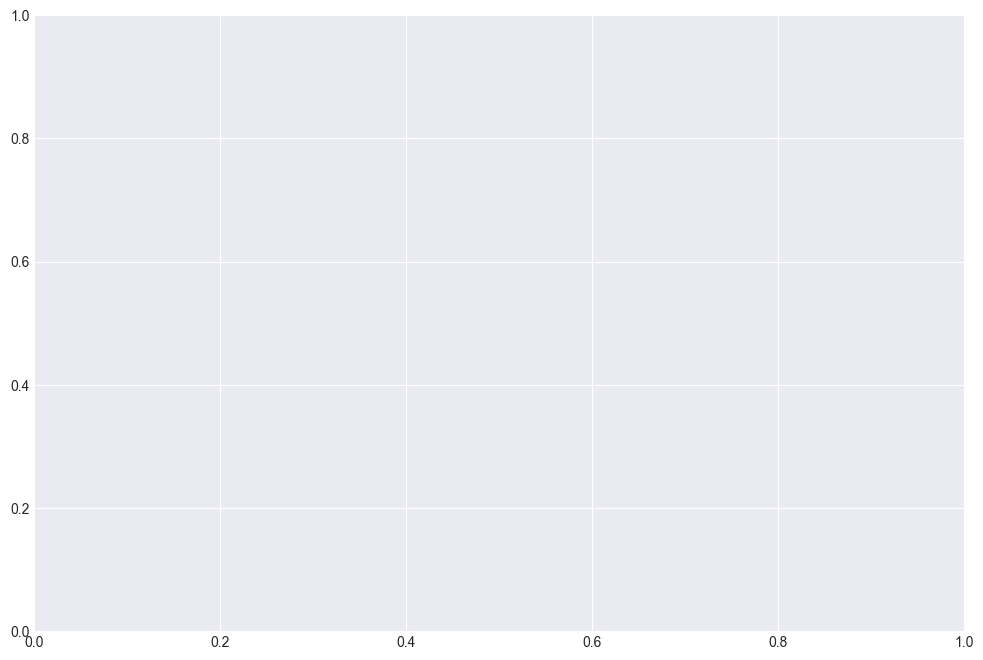

In [11]:
def generate_plots_for_file(filename, data_dict, output_dir):
    """
    Gera gráficos para cada arquivo CSV
    
    Parameters:
    -----------
    filename : str
        Nome do arquivo CSV
    data_dict : dict
        Dicionário contendo 'metadata' e 'dataframe'
    output_dir : Path
        Diretório de saída para salvar gráficos
    
    Returns:
    --------
    dict : Informações sobre os gráficos gerados
    """
    metadata = data_dict['metadata']
    df = data_dict['dataframe']
    
    # Criar diretório específico para este arquivo
    file_output_dir = output_dir / filename.replace('.csv', '')
    file_output_dir.mkdir(exist_ok=True)
    
    # Identificar colunas principais
    cols = df.columns.tolist()
    
    # A primeira coluna é geralmente o pT central, a segunda é pT LOW, terceira pT HIGH
    # A quarta é o valor, seguidas de erros
    if len(cols) < 4:
        print(f"  ⚠ {filename}: Insuficientes colunas")
        return None
    
    pt_col = cols[0]  # pT central
    value_col = cols[3]  # Valor medido
    
    # Identificar colunas de erro usando busca mais robusta
    stat_plus = None
    stat_minus = None
    syst_plus = None
    syst_minus = None
    
    for col in cols:
        col_lower = col.lower()
        if 'stat' in col_lower and ('+' in col_lower or 'plus' in col_lower):
            stat_plus = col
        elif 'stat' in col_lower and ('-' in col_lower or 'minus' in col_lower):
            stat_minus = col
        elif 'syst' in col_lower and 'uncorr' not in col_lower and ('+' in col_lower or 'plus' in col_lower):
            syst_plus = col
        elif 'syst' in col_lower and 'uncorr' not in col_lower and ('-' in col_lower or 'minus' in col_lower):
            syst_minus = col
    
    # Remover linhas com valores ausentes nas colunas principais
    df_clean = df[[pt_col, value_col]].dropna()
    
    # Criar figura com tamanho adequado
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    
    # Calcular erros totais (estatístico + sistemático em quadratura)
    error_plus = np.zeros(len(df_clean))
    error_minus = np.zeros(len(df_clean))
    
    if stat_plus is not None and stat_minus is not None:
        error_plus += df_clean[stat_plus].fillna(0).values ** 2
        error_minus += df_clean[stat_minus].fillna(0).values ** 2
    
    if syst_plus is not None and syst_minus is not None:
        error_plus += df_clean[syst_plus].fillna(0).values ** 2
        error_minus += df_clean[syst_minus].fillna(0).values ** 2
    
    error_plus = np.sqrt(error_plus)
    error_minus = np.sqrt(error_minus)
    
    # Plotar com barras de erro
    ax.errorbar(df_clean[pt_col], df_clean[value_col], 
                yerr=[error_minus, error_plus],
                fmt='o-', markersize=8, linewidth=2.5,
                capsize=5, capthick=2, elinewidth=2,
                label='Medida com erro total', color='#1f77b4', alpha=0.8)
    
    # Customização do gráfico
    centrality = metadata.get('centrality', 'Centralidade Desconhecida')
    title = f"{filename.replace('.csv', '')} - Centralidade: {centrality}%"
    
    if metadata.get('description'):
        title += f"\n{metadata['description']}"
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel(cols[0], fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{value_col.upper()}', fontsize=12, fontweight='bold')
    
    ax.grid(True, which='both', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Adicionar legenda com informações
    legend_text = f"Centralidade: {centrality}%\n"
    if stat_plus and stat_minus:
        legend_text += f"Erro estatístico: ✓\n"
    if syst_plus and syst_minus:
        legend_text += f"Erro sistemático: ✓"
    
    ax.text(0.98, 0.03, legend_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    # Salvar figura
    output_filename = f"{filename.replace('.csv', '')}_centrality_{centrality.replace('-', '_').replace('%', 'pct')}.{OUTPUT_FORMAT}"
    output_path = file_output_dir / output_filename
    
    fig.savefig(output_path, dpi=OUTPUT_DPI, format=OUTPUT_FORMAT, bbox_inches='tight')
    
    # Exibir no notebook
    plt.show()


# Processar todos os arquivos e gerar gráficos
plots_info = []

print("Gerando gráficos...\n")
for filename, data in data_storage.items():
    try:
        result = generate_plots_for_file(filename, data, OUTPUT_BASE_DIR)
        if result:
            plots_info.append(result)
            print(f"✓ {filename:20s} | Centralidade: {result['centrality']:15s} | Pontos: {result['n_points']:4d} | "
                  f"Erro Stat: {'✓' if result['has_stat_error'] else '✗'} | "
                  f"Erro Syst: {'✓' if result['has_syst_error'] else '✗'}")
    except Exception as e:
        print(f"✗ {filename:20s} | Erro: {e}")

print(f"\n✓ Total de gráficos gerados: {len(plots_info)}")

## 5. Geração de Gráficos por Arquivo CSV (Uma curva por centralidade)

In [6]:
def clean_and_standardize_data(df):
    """
    Padroniza e limpa os dados do DataFrame
    """
    df_clean = df.copy()
    
    # Padronizar nomes de colunas: remover espaços, converter para minúsculas
    df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
    
    # Converter para numérico, substituindo erros por NaN
    numeric_cols = df_clean.columns
    for col in numeric_cols:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # Remover linhas completamente vazias
    df_clean = df_clean.dropna(how='all')
    
    # Ordenar por coluna de pT (primeira coluna numérica, geralmente)
    if len(df_clean.columns) > 0:
        df_clean = df_clean.sort_values(by=df_clean.columns[0]).reset_index(drop=True)
    
    return df_clean


# Padronizar todos os dados
for filename, data in data_storage.items():
    data['dataframe'] = clean_and_standardize_data(data['dataframe'])
    df = data['dataframe']
    print(f"{filename:20s} | Colunas: {len(df.columns)} | Linhas válidas: {len(df)}")

print("\nAmostra de colunas do primeiro arquivo:")
print(list(data_storage[list(data_storage.keys())[0]]['dataframe'].columns))

Table01.csv          | Colunas: 10 | Linhas válidas: 589
Table02.csv          | Colunas: 8 | Linhas válidas: 58
Table03.csv          | Colunas: 10 | Linhas válidas: 539
Table04.csv          | Colunas: 8 | Linhas válidas: 53
Table05.csv          | Colunas: 10 | Linhas válidas: 519
Table06.csv          | Colunas: 8 | Linhas válidas: 51
Table07.csv          | Colunas: 10 | Linhas válidas: 539
Table08.csv          | Colunas: 8 | Linhas válidas: 53
Table09.csv          | Colunas: 10 | Linhas válidas: 519
Table10.csv          | Colunas: 8 | Linhas válidas: 51
Table15.csv          | Colunas: 8 | Linhas válidas: 707
Table16.csv          | Colunas: 8 | Linhas válidas: 647
Table17.csv          | Colunas: 8 | Linhas válidas: 539

Amostra de colunas do primeiro arquivo:
['$p_{t}$_[$gev/c$]', '$p_{t}$_[$gev/c$]_low', '$p_{t}$_[$gev/c$]_high', '(1/nev)*d2(n)/dpt/dyrap_[$(gev/c)^{-1}$]', 'stat._+', 'stat._-', 'syst._+', 'syst._-', 'syst._uncorr._+', 'syst._uncorr._-']


## 4. Padronização e Limpeza dos Dados

In [5]:
def extract_metadata_from_csv(filepath):
    """
    Extrai metadados do arquivo CSV (centralidade, descrição, etc.)
    """
    metadata = {
        'file': filepath.name,
        'centrality': 'Desconhecida',
        'description': None,
        'reactions': None,
        'observable': None,
        'energy': None
    }
    
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if line.startswith('#:'):
                    line_clean = line[2:].strip()
                    
                    if 'CENTRALITY' in line_clean:
                        # Extrair centralidade: "CENTRALITY [pct],,,0.0-5.0"
                        parts = line_clean.split(',')
                        if len(parts) >= 4 and parts[3].strip():
                            metadata['centrality'] = parts[3].strip()
                    
                    elif line_clean.startswith('description:'):
                        metadata['description'] = line_clean.replace('description:', '').strip()
                    
                    elif line_clean.startswith('keyword reactions:'):
                        metadata['reactions'] = line_clean.replace('keyword reactions:', '').strip()
                    
                    elif line_clean.startswith('keyword observables:'):
                        metadata['observable'] = line_clean.replace('keyword observables:', '').strip()
                    
                    elif 'cmenergies' in line_clean:
                        parts = line_clean.split(',')
                        if len(parts) >= 4 and parts[3].strip():
                            metadata['energy'] = parts[3].strip()
                
                elif not line.startswith('#'):
                    break
    
    except Exception as e:
        print(f"Erro ao ler {filepath.name}: {e}")
    
    return metadata


def read_csv_data(filepath):
    """
    Lê o arquivo CSV ignorando as linhas de comentário do HEPData
    Tenta ler com engine 'python' para mais flexibilidade
    """
    try:
        # Contar linhas de cabeçalho (começam com #)
        header_lines = 0
        with open(filepath, 'r') as f:
            for line in f:
                if line.startswith('#'):
                    header_lines += 1
                else:
                    break
        
        # Ler o CSV, pulando as linhas de comentário
        # Usa engine='python' para ser mais robusto com formatos variados
        try:
            df = pd.read_csv(filepath, skiprows=header_lines, skipinitialspace=True, engine='python')
        except:
            # Se falhar, tenta com engine padrão (C)
            df = pd.read_csv(filepath, skiprows=header_lines, skipinitialspace=True)
        
        return df
    
    except Exception as e:
        print(f"Erro ao ler dados de {filepath.name}: {e}")
        return None


# Processar todos os arquivos
data_storage = {}

for csv_file in csv_files:
    metadata = extract_metadata_from_csv(csv_file)
    df = read_csv_data(csv_file)
    
    if df is not None:
        data_storage[csv_file.name] = {
            'metadata': metadata,
            'dataframe': df
        }
        centrality_str = metadata['centrality'] if metadata['centrality'] else 'Desconhecida'
        print(f"✓ {csv_file.name:20s} | Centralidade: {centrality_str:15s} | Linhas: {len(df)}")
    else:
        print(f"✗ {csv_file.name:20s} | ERRO NA LEITURA")

✓ Table01.csv          | Centralidade: 0.0-5.0         | Linhas: 625
✓ Table02.csv          | Centralidade: Desconhecida    | Linhas: 58
✓ Table03.csv          | Centralidade: 0.0-5.0         | Linhas: 575
✓ Table04.csv          | Centralidade: Desconhecida    | Linhas: 53
✓ Table05.csv          | Centralidade: 0.0-5.0         | Linhas: 555
✓ Table06.csv          | Centralidade: Desconhecida    | Linhas: 51
✓ Table07.csv          | Centralidade: 0.0-5.0         | Linhas: 584
✓ Table08.csv          | Centralidade: Desconhecida    | Linhas: 53
✓ Table09.csv          | Centralidade: 0.0-5.0         | Linhas: 564
✓ Table10.csv          | Centralidade: Desconhecida    | Linhas: 51
Erro ao ler dados de Table11.csv: Error tokenizing data. C error: Expected 4 fields in line 26, saw 8

✗ Table11.csv          | ERRO NA LEITURA
Erro ao ler dados de Table12.csv: Error tokenizing data. C error: Expected 4 fields in line 17, saw 6

✗ Table12.csv          | ERRO NA LEITURA
Erro ao ler dados de Table1

## 3. Leitura de Arquivos CSV e Extração de Metadados

In [2]:
# Descobrir todos os arquivos Table*.csv
csv_files = sorted(DATA_DIR.glob("Table*.csv"))
print(f"Total de arquivos encontrados: {len(csv_files)}\n")

for i, file in enumerate(csv_files, 1):
    size_kb = file.stat().st_size / 1024
    print(f"{i:2d}. {file.name:20s} ({size_kb:8.1f} KB)")

Total de arquivos encontrados: 17

 1. Table01.csv          (    47.2 KB)
 2. Table02.csv          (     4.4 KB)
 3. Table03.csv          (    44.2 KB)
 4. Table04.csv          (     4.1 KB)
 5. Table05.csv          (    43.6 KB)
 6. Table06.csv          (     4.0 KB)
 7. Table07.csv          (    46.0 KB)
 8. Table08.csv          (     3.9 KB)
 9. Table09.csv          (    45.4 KB)
10. Table10.csv          (     3.9 KB)
11. Table11.csv          (     1.8 KB)
12. Table12.csv          (     0.8 KB)
13. Table13.csv          (     1.9 KB)
14. Table14.csv          (     0.8 KB)
15. Table15.csv          (    46.2 KB)
16. Table16.csv          (    41.1 KB)
17. Table17.csv          (    35.1 KB)


## 2. Descoberta de Arquivos CSV

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings

warnings.filterwarnings('ignore')

# Configuração visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Parâmetros de saída
OUTPUT_DPI = 300
OUTPUT_FORMAT = 'png'
FIGURE_SIZE = (12, 8)

# Diretórios
DATA_DIR = Path("/Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Atlas-ins1759506")
OUTPUT_BASE_DIR = Path("/Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Atlas-ins1759506-plots")
OUTPUT_BASE_DIR.mkdir(exist_ok=True)

print(f"Diretório de dados: {DATA_DIR}")
print(f"Diretório de saída: {OUTPUT_BASE_DIR}")
print(f"DPI: {OUTPUT_DPI}, Formato: {OUTPUT_FORMAT}")

Diretório de dados: /Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Atlas-ins1759506
Diretório de saída: /Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Atlas-ins1759506-plots
DPI: 300, Formato: png


## 1. Configuração do Ambiente e Parâmetros

# Análise de Dados Atlas ins1759506 - Distribuições de pT por Centralidade

Este notebook processa os arquivos CSV do experimento Atlas ins1759506 e gera gráficos separados para cada centralidade, explicitando todas as informações (valores medidos, erros estatísticos, erros sistemáticos correlacionados e não correlacionados).